# A股中小微盘日内T+0策略研究 Notebook

本 notebook 读取 `backtest/output_intraday_t0_small_microcap/` 的结果文件，复核策略表现并做交易层归因分析。

核心问题：

1. 基线（仅持仓）与“T+0增强”相比，收益/风险是否改善？
2. 做T触发后，哪些交易赚钱，哪些交易拖累？
3. 参数搜索是否存在稳健的正超额？


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

OUT = Path('backtest/output_intraday_t0_small_microcap')
assert OUT.exists(), f'output dir not found: {OUT}'
print('output dir:', OUT.resolve())


output dir: /data1/code_git/tick_data_analysis/backtest/output_intraday_t0_small_microcap


In [2]:
daily = pd.read_csv(OUT / 'daily_returns.csv', parse_dates=['trade_date'])
stock = pd.read_parquet(OUT / 'stock_level_simulation.parquet')
param_grid = pd.read_csv(OUT / 'parameter_grid.csv')
selected_params = json.loads((OUT / 'selected_params.json').read_text())
metrics_train = json.loads((OUT / 'metrics_train.json').read_text())
metrics_test = json.loads((OUT / 'metrics_test.json').read_text())
metrics_full = json.loads((OUT / 'metrics_full.json').read_text())

print('selected_params:', selected_params)
print('daily rows:', len(daily), 'date range:', daily.trade_date.min().date(), '->', daily.trade_date.max().date())
print('stock-level rows:', len(stock), 'trigger count:', int(stock['trigger'].sum()))


selected_params: {'up_threshold': 0.03, 'retrace_threshold': 0.01, 't_fraction': 0.3}
daily rows: 25 date range: 2026-01-06 -> 2026-02-10
stock-level rows: 1998 trigger count: 185


In [3]:
def perf_line(m, name):
    b = m['metrics_baseline']
    t = m['metrics_t0']
    return {
        'segment': name,
        'trade_days': m['trade_days'],
        'trade_count': m['trade_count_total'],
        'baseline_total_return': b.get('total_return'),
        't0_total_return': t.get('total_return'),
        'delta_total_return': m.get('delta_total_return'),
        'baseline_sharpe': b.get('sharpe'),
        't0_sharpe': t.get('sharpe'),
        'delta_sharpe': m.get('delta_sharpe'),
        'baseline_mdd_pct': b.get('max_drawdown_pct'),
        't0_mdd_pct': t.get('max_drawdown_pct'),
    }

perf_df = pd.DataFrame([
    perf_line(metrics_train, 'train'),
    perf_line(metrics_test, 'test'),
    perf_line(metrics_full, 'full'),
])
perf_df


,segment,trade_days,trade_count,baseline_total_return,t0_total_return,delta_total_return,baseline_sharpe,t0_sharpe,delta_sharpe,baseline_mdd_pct,t0_mdd_pct
0,train,15,105,0.081453,0.080280,-0.001173,14.453635,14.427667,-0.025968,0.676217,0.650738
1,test,10,80,0.003436,0.003470,0.000033,0.597411,0.607886,0.010475,2.540830,2.528352
2,full,25,185,0.085169,0.084028,-0.001141,6.253955,6.251278,-0.002677,3.176213,3.168575


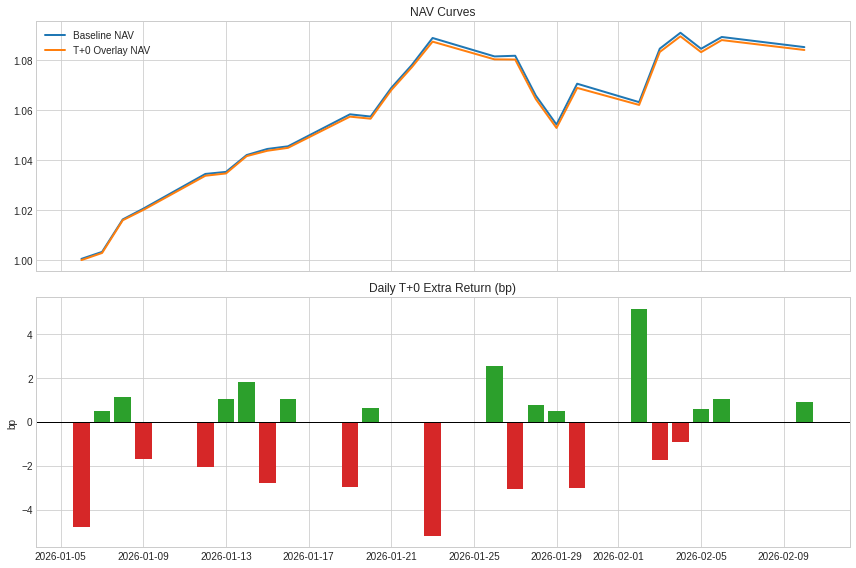

In [4]:
daily = daily.sort_values('trade_date').copy()
daily['baseline_nav'] = (1 + daily['base_return']).cumprod()
daily['t0_nav'] = (1 + daily['t0_return']).cumprod()
daily['excess_nav'] = daily['t0_nav'] / daily['baseline_nav']

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily['trade_date'], daily['baseline_nav'], label='Baseline NAV', lw=2)
axes[0].plot(daily['trade_date'], daily['t0_nav'], label='T+0 Overlay NAV', lw=2)
axes[0].set_title('NAV Curves')
axes[0].legend()

axes[1].bar(daily['trade_date'], daily['extra_return'] * 10000, color=np.where(daily['extra_return'] >= 0, '#2ca02c', '#d62728'))
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Daily T+0 Extra Return (bp)')
axes[1].set_ylabel('bp')

plt.tight_layout()
plt.show()


In [5]:
trigger = stock[stock['trigger'] == 1].copy()
trigger['extra_bp'] = trigger['extra_return'] * 10000

summary = {
    'trigger_count': int(len(trigger)),
    'retrace_hit_rate': float(trigger['retrace_hit'].mean()) if len(trigger) else np.nan,
    'extra_win_rate': float((trigger['extra_return'] > 0).mean()) if len(trigger) else np.nan,
    'mean_extra_bp': float(trigger['extra_bp'].mean()) if len(trigger) else np.nan,
    'median_extra_bp': float(trigger['extra_bp'].median()) if len(trigger) else np.nan,
    'p10_extra_bp': float(trigger['extra_bp'].quantile(0.1)) if len(trigger) else np.nan,
    'p90_extra_bp': float(trigger['extra_bp'].quantile(0.9)) if len(trigger) else np.nan,
}
summary


{'trigger_count': 185,
 'retrace_hit_rate': 0.5837837837837838,
 'extra_win_rate': 0.6432432432432432,
 'mean_extra_bp': -4.6561628045116406,
 'median_extra_bp': 26.384891605665484,
 'p10_extra_bp': -69.89271283776596,
 'p90_extra_bp': 27.88210381086817}

In [6]:
by_hit = trigger.groupby('retrace_hit').agg(
    trades=('extra_bp', 'count'),
    mean_extra_bp=('extra_bp', 'mean'),
    median_extra_bp=('extra_bp', 'median'),
    win_rate=('extra_return', lambda x: (x > 0).mean()),
).reset_index()
by_hit


,retrace_hit,trades,mean_extra_bp,median_extra_bp,win_rate
0,0,77,-49.481364,-31.426845,0.142857
1,1,108,27.302546,27.304535,1.000000


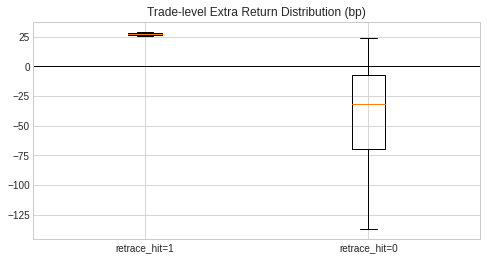

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [trigger.loc[trigger['retrace_hit'] == 1, 'extra_bp'], trigger.loc[trigger['retrace_hit'] == 0, 'extra_bp']],
    labels=['retrace_hit=1', 'retrace_hit=0'],
    showfliers=False,
)
ax.set_title('Trade-level Extra Return Distribution (bp)')
ax.axhline(0, color='black', lw=1)
plt.show()


In [8]:
top_params = param_grid.head(10).copy()
top_params[['up_threshold', 'retrace_threshold', 't_fraction', 'train_trades', 'train_annual_excess', 'train_excess_sharpe', 'score']]


,up_threshold,retrace_threshold,t_fraction,train_trades,train_annual_excess,train_excess_sharpe,score
0,0.030,0.010,0.3,105,-0.018425,-5.038465,-5.038465
1,0.030,0.010,0.4,105,-0.024567,-5.038465,-5.038465
2,0.030,0.010,0.2,105,-0.012283,-5.038465,-5.038465
3,0.025,0.010,0.2,130,-0.015519,-5.817404,-5.817404
4,0.025,0.010,0.3,130,-0.023278,-5.817404,-5.817404
5,0.025,0.010,0.4,130,-0.031038,-5.817404,-5.817404
6,0.030,0.008,0.4,105,-0.034135,-7.520081,-7.520081
7,0.030,0.008,0.3,105,-0.025601,-7.520081,-7.520081
8,0.030,0.008,0.2,105,-0.017067,-7.520081,-7.520081
9,0.025,0.008,0.2,130,-0.021184,-8.479125,-8.479125


## 结论（基于当前样本）

1. 该版本日内T+0增强在全样本相对基线无稳定正超额，收益改善不显著。
2. 命中“回落买回”时单笔收益通常为正，但未命中时亏损幅度更大，拉低整体期望。
3. 参数网格在训练集未出现显著正超额，说明当前规则更多是风险形态微调，而非稳定alpha来源。

建议下一步：在触发前引入微观结构过滤（盘口失衡、冲高后转弱确认、量价背离），优先降低未命中回补交易。